In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('D:\\data analyst\\dataproject\\3_customer_churn\\Customer-churn-analysis\\Dataset\\customer_churn.csv')

## Understanding data

In [4]:

print('=' * 50, 'Number of columns and rows', '=' * 50, end='\n\n')
print(df.shape)
print('=' * 50, 'Sample data', '=' * 50, end='\n\n')
print(df.sample(10))
print('=' * 50, 'Data types and null value count', '=' * 50, end='\n\n')
print(df.info())
print('=' * 50, 'Statistics summary ', '=' * 50, end='\n\n')
print(df.describe(include='all'))
print('=' * 50, 'Null value count', '=' * 50, end='\n\n')
print(df.isnull().sum())
print('=' * 50, 'Duplicate value count', '=' * 50, end='\n\n')
print(df.duplicated().sum())
print('=' * 50, 'Unique value count', '=' * 50, end='\n\n')
print(df.nunique())

for col in df.columns:
    print('=' * 50, f'Unique values in {col}', '=' * 50, end='\n\n')
    print(df[col].unique())

================================================== Number of columns and rows ==================================================

(7043, 21)
================================================== Sample data ==================================================

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
6208  0909-SELIE    Male              0     Yes         No      61   
609   3419-SNJJD  Female              1     Yes         No      65   
5432  1597-FZREH  Female              0      No         No       2   
3959  8788-DOXSU    Male              0      No         No      59   
2035  8100-HZZLJ  Female              0      No        Yes      43   
6055  6599-SFQVE  Female              0      No         No       6   
5072  5995-SNNEW    Male              1     Yes         No      23   
4549  2074-GUHPQ  Female              0      No        Yes      17   
2587  5849-ASHZJ    Male              0      No        Yes      27   
1029  4184-TJFAN  Female              1     

## Data cleaning

In [5]:
# !!!!!!!!!!!!!!!!!! Making a copy (never edit the original dataframe) !!!!!!!!!!!!!!!!!!
# del cleaned_df
cleaned_df = df.copy()

In [6]:
# !!!!!!!!!!!!!!!! captalizing and striping empty sapces from columns !!!!!!!!!!!!!!!!!!!
cleaned_df.columns=cleaned_df.columns.str.capitalize().str.strip()
# !!!!!!!!!!!!!!!!!!!!!!!!!! Dropping duplicates !!!!!!!!!!!!!!!!!!!!!!!!!!!!!
cleaned_df.drop_duplicates(inplace=True)

#   !!!!!!!!!!!!!!change data types of columns !!!!!!!!!!!!!!!!!!
# cleaned_df['Totalharges']=cleaned_df['Totalcharges'].astype(float)

#  this did not work as there are spce in place of null valess so we use the following method to convert the column to numeric and coerce errors to NaN
cleaned_df['Totalcharges'] = pd.to_numeric(cleaned_df['Totalcharges'], errors='coerce')
cleaned_df['Totalcharges'] = cleaned_df['Totalcharges'].fillna(0)
cleaned_df.dropna(inplace=True)
cleaned_df['Seniorcitizen']=cleaned_df['Seniorcitizen'].astype('object')
cleaned_df['Seniorcitizen']=cleaned_df['Seniorcitizen'].replace({1: 'senior', 0: 'non senior'})

## Creating measures and visualisation

In [7]:
cleaned_df.to_csv('D:\\data analyst\\dataproject\\3_customer_churn\\c;eaned_customer_churn.csv')

In [8]:
r,c=3,3
churnrate=(cleaned_df['Churn'].value_counts())
print(churnrate,end='\n\n')
genderchurn=pd.crosstab(cleaned_df['Gender'],cleaned_df['Churn'])
print(genderchurn,end='\n\n')
Dependentschurn=pd.crosstab(cleaned_df['Dependents'],cleaned_df['Churn'])
print(Dependentschurn,end='\n\n')
seniorchurn=pd.crosstab(cleaned_df['Seniorcitizen'],cleaned_df['Churn'])
print(seniorchurn,end='\n\n')
partnerchurn=pd.crosstab(cleaned_df['Partner'],cleaned_df['Churn'])
print(partnerchurn,end='\n\n')
contractchurn=pd.crosstab(cleaned_df['Contract'],cleaned_df['Churn'])
print(contractchurn,end='\n\n')
paymentchurn=pd.crosstab(cleaned_df['Paymentmethod'],cleaned_df['Churn'])
print(paymentchurn,end='\n\n')
techsupportchurn = (
    pd.crosstab(
        df["TechSupport"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)
print(techsupportchurn,end='\n\n')

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn     No  Yes
Gender           
Female  2549  939
Male    2625  930

Churn         No   Yes
Dependents            
No          3390  1543
Yes         1784   326

Churn            No   Yes
Seniorcitizen            
non senior     4508  1393
senior          666   476

Churn      No   Yes
Partner            
No       2441  1200
Yes      2733   669

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48

Churn                        No   Yes
Paymentmethod                        
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308

Churn                   No    Yes
TechSupport                      
No                   58.36  41.64
No internet service  92.60   7.40
Yes                  84.83  15.17



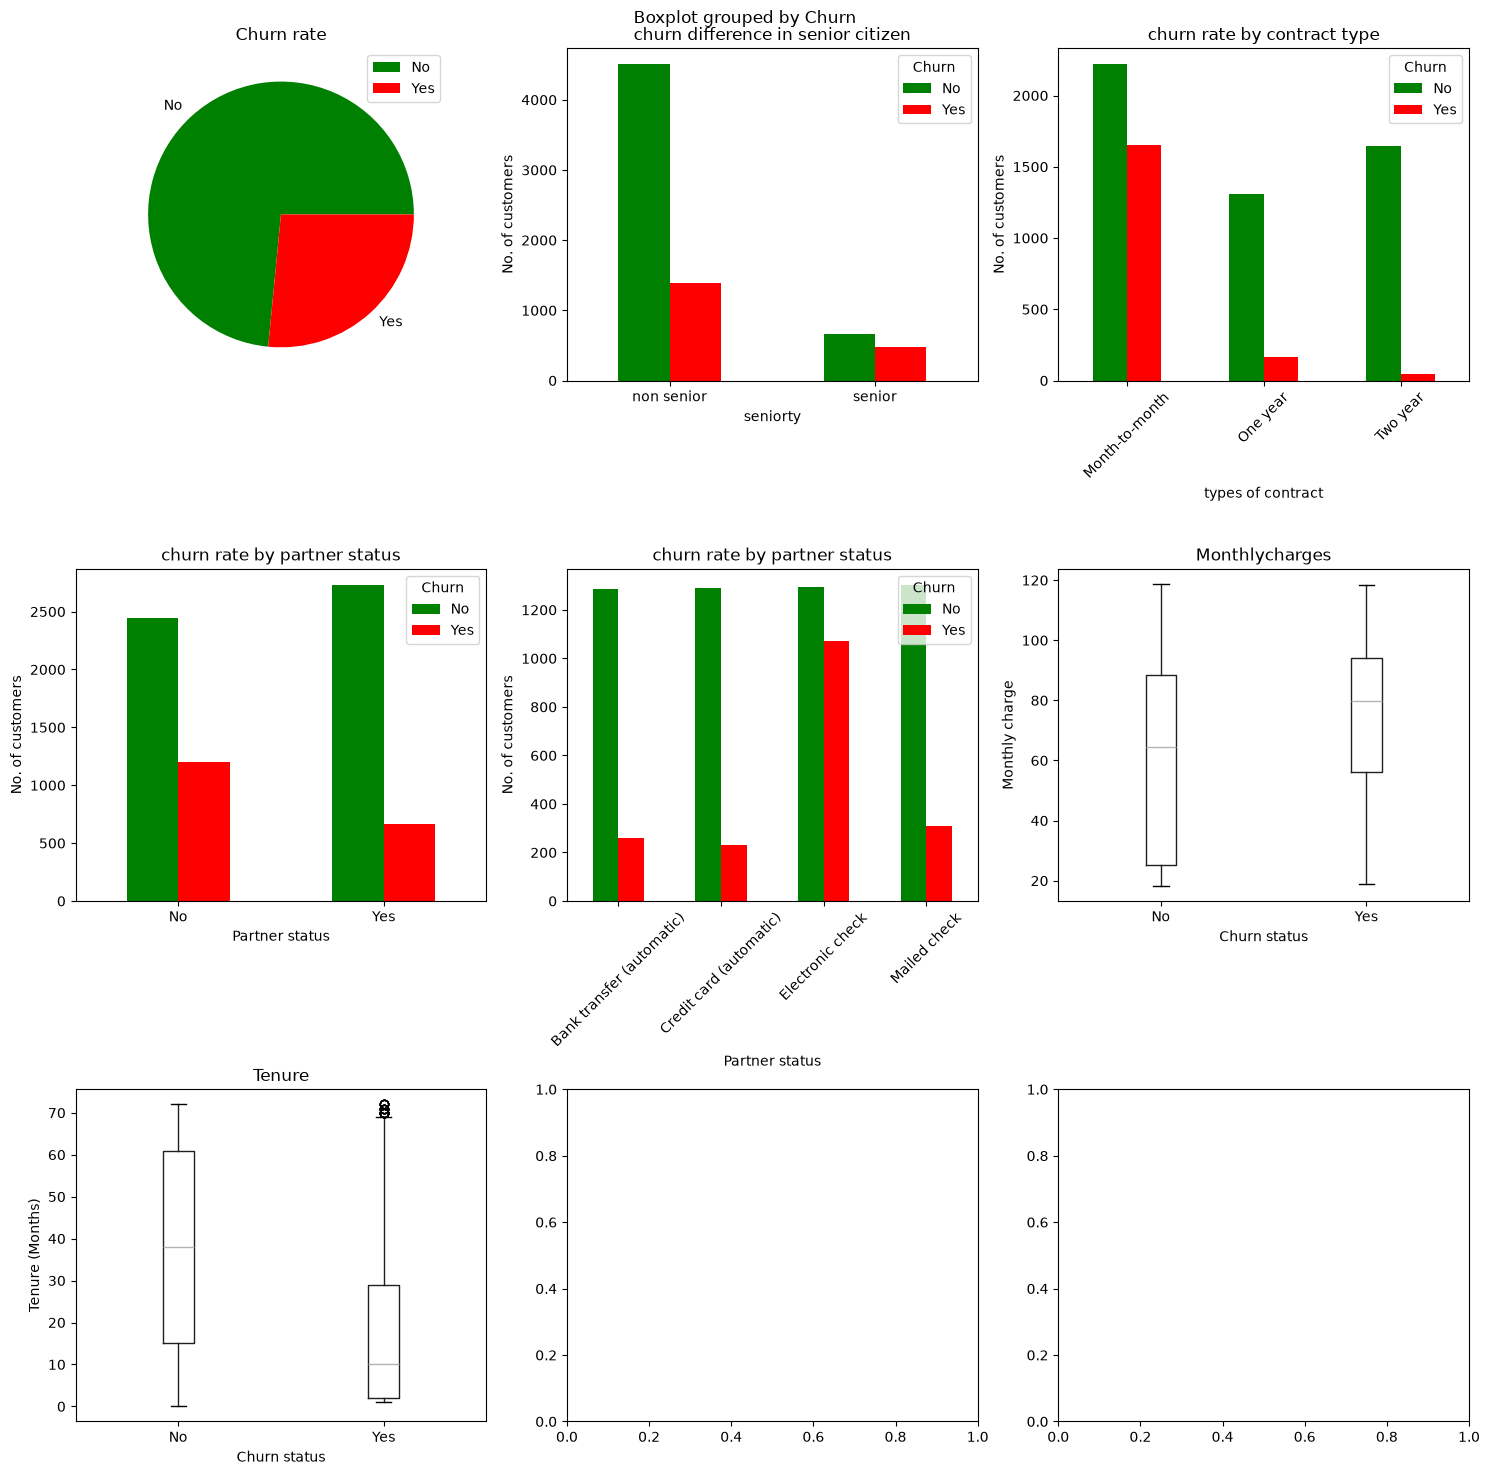

In [9]:
churncolor={
    'No':'green','Yes':'red',
}
fig, axes = plt.subplots(r, c, figsize=(15,15))
axes=axes.flatten()
churnrate.plot(
    kind='pie',
    ax=axes[0],
    labels=churnrate.index,
    title='Churn rate',
    legend=True,
    colors=[churncolor.get(label,'gray')for label in seniorchurn.columns],
    
)
axes[0].set_ylabel('')

seniorchurn.plot(
    kind='bar',
    ylabel='No. of customers',
    xlabel='seniorty',
    color=[churncolor.get(label,'gray')for label in seniorchurn.columns],
    title='churn difference in senior citizen',
    ax=axes[1],
)

contractchurn.plot(kind='bar',
                 title='churn rate by contract type',
                 ylabel='No. of customers',
                 xlabel='types of contract',
                 color=[churncolor.get(label,'gray')for label in contractchurn.columns],
                 ax=axes[2])

partnerchurn.plot(kind='bar',
                 title='churn rate by partner status',
                 ylabel='No. of customers',
                 xlabel='Partner status',
                 color=[churncolor.get(label,'gray')for label in partnerchurn.columns],
                 ax=axes[3],
                 )
paymentchurn.plot(kind='bar',
                 title='churn rate by partner status',
                 ylabel='No. of customers',
                 xlabel='Partner status',
                 color=[churncolor.get(label,'gray')for label in partnerchurn.columns],
                 ax=axes[4],
                 )
cleaned_df.boxplot(
                column='Monthlycharges',
                by='Churn',
                ax=axes[5],
                grid=False,
                ylabel='Monthly charge',
                xlabel='Churn status'
                )
cleaned_df.boxplot(
                column='Tenure',
                by='Churn',
                ax=axes[6],
                grid=False,
                ylabel='Tenure (Months)',
                xlabel='Churn status'
                )




axes[1].tick_params(axis='x', rotation=0)
axes[2].tick_params(axis='x', rotation=45)
axes[3].tick_params(axis='x', rotation=0)
axes[4].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Key Insights from Customer Churn Analysis

* The overall **customer churn rate is 26.54%**, meaning that more than one-fourth of the total customer base has discontinued their subscription. This is significantly high for a subscription-based company and may negatively impact recurring revenue, customer retention, and long-term business growth.

* **Gender does not appear to have a significant impact on the churn rate**, as the churn behavior of male and female customers is relatively similar.

* **Senior citizen status appears to have a significant impact on churn.** Senior citizens have a considerably higher churn rate compared with non-senior citizens, making them an important customer segment for targeted retention strategies.

* **Contract type is one of the most influential factors affecting customer churn.** Customers with **month-to-month contracts account for the highest level of churn**, likely because they have greater flexibility and lower commitment. Customers with longer-term contracts generally show better retention.

* **Electronic check appears to be a high-risk payment method**, as customers using electronic checks show a higher churn rate compared with customers using other payment methods. This may indicate potential issues related to payment convenience, payment failures, or customer preferences.

* **Customer tenure is another important factor influencing churn.** Churn is particularly high during the initial months of the customer relationship. This suggests that new customers may not yet be fully engaged or satisfied with the service. Improving the onboarding experience and providing additional support during the early months could help reduce early-stage churn.

* **Partner status may also be associated with customer churn.** Customers without a partner appear to have a higher churn rate compared with customers who have a partner. However, the total number of non-partner customers is lower than the number of customers with partners, so both the churn rate and the total customer population should be considered before drawing a final conclusion.

* **Customer support appears to play an important role in reducing churn.** Customers who receive effective support show a significantly lower churn rate, decreasing from approximately **41% to 15%**. This suggests that improving customer service and support quality may be an effective strategy for increasing customer satisfaction and retention.

### Overall Business Insight

The analysis suggests that customer churn is primarily associated with **month-to-month contracts, electronic check payment methods, short customer tenure, senior citizen status, and the availability and effectiveness of customer support**. The company should focus on improving the onboarding experience for new customers, encouraging longer-term contracts, reviewing the electronic check payment process, and strengthening customer support services.

These targeted strategies could help reduce churn, improve customer retention, and increase the long-term value of the customer base.
